# Step 8-9 — M0 linkage (broad / balanced / strict) and quality checks

Interactive version of `scripts/run_m0_linkage.py` — **running this notebook regenerates the link
files, the balanced survival dataset, and all `m0_*` QA tables** under `reports/tables/`.

Thresholds are derived from the observed distribution of best-candidate (rank-1) composite scores
(25th/50th/75th percentile), not hardcoded a priori.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

CODE_STR_COLS = ["buyer_siret_clean", "buyer_siren_clean", "cpv_clean",
                  "cpv_division", "cpv_group", "cpv_class", "cpv_category"]

clean = pd.read_csv(PROCESSED_DIR / "boamp_clean_m0_no_enrichment.csv", low_memory=False,
                     dtype={c: str for c in CODE_STR_COLS},
                     parse_dates=["publication_date", "start_date"])
sources = pd.read_csv(PROCESSED_DIR / "boamp_m0_sources.csv",
                       dtype={c: str for c in CODE_STR_COLS},
                       parse_dates=["publication_date", "start_date", "estimated_end_date", "study_end_date"])
pairs = pd.read_csv(PROCESSED_DIR / "boamp_m0_candidate_pairs.csv",
                     parse_dates=["source_date", "candidate_date", "expected_end_date"])
eligible_sources = sources[sources["buyer_key_type"] != "MISSING"]
print(f"clean: {len(clean)} rows | sources: {len(sources)} | eligible: {len(eligible_sources)} | pairs: {len(pairs)}")

clean: 84623 rows | sources: 3159 | eligible: 3159 | pairs: 6137


## Derive thresholds from the rank-1 score distribution

In [2]:
rank1 = pairs[pairs["candidate_rank"] == 1] if len(pairs) else pd.DataFrame(columns=pairs.columns)
if len(rank1):
    p25, p50, p75 = rank1["m0_composite_score"].quantile([0.25, 0.5, 0.75]).tolist()
else:
    p25 = p50 = p75 = 0.0
thresholds = {"broad": p25, "balanced": p50, "strict": p75}
print(f"Derived thresholds from rank-1 composite score distribution: {thresholds}")

Derived thresholds from rank-1 composite score distribution: {'broad': 0.26420166983556403, 'balanced': 0.32302169365652333, 'strict': 0.39308340344166265}


## Build the three link variants

In [3]:
def build_variant(pairs: pd.DataFrame, threshold: float, variant_name: str) -> pd.DataFrame:
    rank1 = pairs[pairs["candidate_rank"] == 1].copy()
    linked = rank1[rank1["m0_composite_score"] >= threshold].copy()
    linked["variant"] = variant_name
    linked["threshold_used"] = threshold
    cols = ["source_notice_id", "candidate_notice_id", "buyer_key", "buyer_key_type",
            "source_date", "candidate_date", "gap_months", "expected_end_date",
            "abs_gap_to_expected_end", "s_time", "s_text", "s_cpv", "s_buyer",
            "m0_composite_score", "cpv_missing", "cpv_generic_flag",
            "candidate_rank", "top1_top2_margin", "n_candidates_for_source",
            "variant", "threshold_used"]
    return linked[cols]


variants = {}
for name, thr in thresholds.items():
    variants[name] = build_variant(pairs, thr, name)
    out_path = PROCESSED_DIR / f"boamp_m0_links_{name}.csv"
    variants[name].to_csv(out_path, index=False)
    print(f"Wrote {out_path} ({len(variants[name])} links)")

Wrote /home/senghakrou/survival-analysis/data/processed/boamp_m0_links_broad.csv (927 links)
Wrote /home/senghakrou/survival-analysis/data/processed/boamp_m0_links_balanced.csv (618 links)
Wrote /home/senghakrou/survival-analysis/data/processed/boamp_m0_links_strict.csv (309 links)


## Build the balanced survival dataset

Every eligible source becomes one row: linked sources get `event=1` at the observed gap; unlinked
sources are censored at the study end date.

In [4]:
def build_survival_dataset(sources: pd.DataFrame, links: pd.DataFrame, variant_name: str) -> pd.DataFrame:
    eligible = sources[sources["buyer_key_type"] != "MISSING"].copy()
    link_map = links.set_index("source_notice_id")

    def row_to_survival(row):
        nid = row["notice_id"]
        study_end = row["study_end_date"]
        if nid in link_map.index:
            link = link_map.loc[nid]
            event = 1
            time_months = link["gap_months"]
            candidate_id = link["candidate_notice_id"]
            score = link["m0_composite_score"]
        else:
            event = 0
            time_months = (study_end - row["publication_date"]).total_seconds() / (3600 * 24 * 30.44)
            candidate_id = None
            score = None
        return pd.Series({
            "notice_id": nid,
            "buyer_key": row["buyer_key"],
            "buyer_key_type": row["buyer_key_type"],
            "publication_date": row["publication_date"],
            "start_date": row["start_date"],
            "estimated_end_date": row["estimated_end_date"],
            "study_end_date": study_end,
            "cpv_division": row["cpv_division"],
            "cpv_category": row["cpv_category"],
            "category_label": row["category_label"],
            "is_digital_scope": row["is_digital_scope"],
            "declared_duration_months": row["declared_duration_months"],
            "dur_was_imputed": row["dur_was_imputed"],
            "event": event,
            "time_to_event_or_censor_months": time_months,
            "linked_candidate_notice_id": candidate_id,
            "m0_composite_score": score,
            "variant": variant_name,
        })

    return eligible.apply(row_to_survival, axis=1)


survival = build_survival_dataset(sources, variants["balanced"], "balanced")
survival_path = PROCESSED_DIR / "boamp_survival_m0_balanced.csv"
survival.to_csv(survival_path, index=False)
print(f"Wrote survival dataset -> {survival_path} ({len(survival)} rows, {survival['event'].sum()} events)")
display(survival.head(3))

Wrote survival dataset -> /home/senghakrou/survival-analysis/data/processed/boamp_survival_m0_balanced.csv (3159 rows, 618 events)


,notice_id,buyer_key,buyer_key_type,publication_date,start_date,estimated_end_date,study_end_date,cpv_division,cpv_category,category_label,is_digital_scope,declared_duration_months,dur_was_imputed,event,time_to_event_or_censor_months,linked_candidate_notice_id,m0_composite_score,variant
0,15-46309,SIRET:22720002900014,RAW_SIRET,2015-03-26,2015-07-29,2018-07-29,2026-07-13,32,32584,DIGITAL_ICT,True,36.0,True,0,135.578187,None,NaN,balanced
1,15-39486,NAME:altantic eau,NAME_FALLBACK,2015-03-16,2015-03-16,2015-09-16,2026-07-13,NaN,NaN,DIGITAL_ICT,True,6.0,True,0,135.906702,None,NaN,balanced
2,15-30947,NAME:smictom de la vallee de l authion,NAME_FALLBACK,2015-03-02,2015-03-02,2019-03-02,2026-07-13,48,48000,DIGITAL_ICT,True,48.0,True,0,136.366623,None,NaN,balanced


## QA tables (`reports/tables/m0_*.csv`)

In [5]:
method_rows = []
for name, thr in thresholds.items():
    linked = variants[name]
    method_rows.append({
        "variant": name,
        "threshold_composite_score": thr,
        "n_sources_eligible": len(eligible_sources),
        "n_linked_events": len(linked),
        "event_rate": len(linked) / len(eligible_sources) if len(eligible_sources) else 0.0,
        "median_gap_months_linked": linked["gap_months"].median() if len(linked) else np.nan,
        "median_composite_score_linked": linked["m0_composite_score"].median() if len(linked) else np.nan,
    })
method_summary = pd.DataFrame(method_rows)
method_summary.to_csv(TABLES_DIR / "m0_method_summary.csv", index=False)
display(method_summary)

,variant,threshold_composite_score,n_sources_eligible,n_linked_events,event_rate,median_gap_months_linked,median_composite_score_linked
0,broad,0.264202,3159,927,0.293447,37.877792,0.352523
1,balanced,0.323022,3159,618,0.195632,37.697109,0.393103
2,strict,0.393083,3159,309,0.097816,44.678055,0.483502


In [6]:
sources_with_year = sources.assign(publication_year=sources["publication_date"].dt.year)
event_rows = []
for name in thresholds:
    linked_ids = set(variants[name]["source_notice_id"])
    for year, grp in sources_with_year[sources_with_year["buyer_key_type"] != "MISSING"].groupby("publication_year"):
        n_events = grp["notice_id"].isin(linked_ids).sum()
        event_rows.append({
            "variant": name, "publication_year": int(year),
            "n_sources": len(grp), "n_events": int(n_events),
            "event_rate": n_events / len(grp) if len(grp) else 0.0,
        })
event_counts = pd.DataFrame(event_rows)
event_counts.to_csv(TABLES_DIR / "m0_event_counts.csv", index=False)
display(event_counts.pivot(index="publication_year", columns="variant", values="n_events"))

variant,balanced,broad,strict
publication_year,,,
2015,82,121,42
2016,82,128,41
2017,107,153,65
2018,83,119,38
2019,68,114,30
2020,53,82,26
2021,41,65,17
2022,20,39,10
2023,10,13,7


In [7]:
score_cols = ["m0_composite_score", "s_text", "s_cpv", "s_time", "s_buyer"]
dist_rows = []
for label, frame in [("all_candidate_pairs", pairs), ("rank1_best_candidate", rank1)]:
    for col in score_cols:
        if col not in frame.columns or not len(frame):
            continue
        desc = frame[col].describe(percentiles=[0.25, 0.5, 0.75])
        dist_rows.append({
            "population": label, "score": col,
            "count": desc.get("count"), "mean": desc.get("mean"), "std": desc.get("std"),
            "min": desc.get("min"), "p25": desc.get("25%"), "p50": desc.get("50%"),
            "p75": desc.get("75%"), "max": desc.get("max"),
        })
score_dist = pd.DataFrame(dist_rows)
score_dist.to_csv(TABLES_DIR / "m0_score_distribution_summary.csv", index=False)
display(score_dist)

,population,score,count,mean,std,min,p25,p50,p75,max
0,all_candidate_pairs,m0_composite_score,6137.0,0.250497,0.110876,0.06,0.171744,0.240778,0.308204,0.938148
1,all_candidate_pairs,s_text,6137.0,0.083416,0.155049,0.00,0.011194,0.027304,0.088577,1.000000
2,all_candidate_pairs,s_cpv,6137.0,0.103226,0.179224,0.00,0.000000,0.100000,0.100000,1.000000
3,all_candidate_pairs,s_time,6137.0,0.498156,0.291157,0.00,0.238940,0.501752,0.753614,1.000000
4,all_candidate_pairs,s_buyer,6137.0,0.657944,0.140795,0.60,0.600000,0.600000,0.600000,1.000000
5,rank1_best_candidate,m0_composite_score,1236.0,0.345073,0.141671,0.06,0.264202,0.323022,0.393083,0.938148
6,rank1_best_candidate,s_text,1236.0,0.180047,0.271655,0.00,0.014938,0.052903,0.217089,1.000000
7,rank1_best_candidate,s_cpv,1236.0,0.176861,0.277960,0.00,0.000000,0.100000,0.200000,1.000000
8,rank1_best_candidate,s_time,1236.0,0.648939,0.285998,0.00,0.457950,0.731713,0.890495,1.000000
9,rank1_best_candidate,s_buyer,1236.0,0.667638,0.149995,0.60,0.600000,0.600000,0.600000,1.000000


In [8]:
bkt_all = clean["buyer_key_type"].value_counts(dropna=False).rename("n_all_notices")
bkt_sources = sources["buyer_key_type"].value_counts(dropna=False).rename("n_appel_offre_sources")
bkt_events_balanced = sources[sources["notice_id"].isin(variants["balanced"]["source_notice_id"])]["buyer_key_type"].value_counts(dropna=False).rename("n_balanced_events")
bkt_summary = pd.concat([bkt_all, bkt_sources, bkt_events_balanced], axis=1).fillna(0).astype(int)
bkt_summary.index.name = "buyer_key_type"
bkt_summary.reset_index().to_csv(TABLES_DIR / "m0_buyer_key_type_summary.csv", index=False)
display(bkt_summary)

,n_all_notices,n_appel_offre_sources,n_balanced_events
buyer_key_type,,,
NAME_FALLBACK,61585,2446,480
RAW_SIRET,23038,713,138


In [9]:
top_buyers_balanced = (
    sources[sources["notice_id"].isin(variants["balanced"]["source_notice_id"])]
    .groupby("buyer_key").size().sort_values(ascending=False).head(10)
)
n_sources_with_candidates = pairs["source_notice_id"].nunique() if len(pairs) else 0
dq_rows = [
    {"metric": "n_eligible_sources", "value": len(eligible_sources)},
    {"metric": "n_candidate_pairs_total", "value": len(pairs)},
    {"metric": "avg_candidates_per_source", "value": pairs.groupby("source_notice_id").size().mean() if len(pairs) else 0.0},
    {"metric": "sources_without_candidates", "value": len(eligible_sources) - n_sources_with_candidates},
    {"metric": "broad_event_count", "value": len(variants["broad"])},
    {"metric": "balanced_event_count", "value": len(variants["balanced"])},
    {"metric": "strict_event_count", "value": len(variants["strict"])},
    {"metric": "top_buyer_balanced_events_max", "value": int(top_buyers_balanced.iloc[0]) if len(top_buyers_balanced) else 0},
]
pd.DataFrame(dq_rows).to_csv(TABLES_DIR / "m0_data_quality_summary.csv", index=False)
display(pd.DataFrame(dq_rows))

,metric,value
0,n_eligible_sources,3159.00000
1,n_candidate_pairs_total,6137.00000
2,avg_candidates_per_source,4.96521
3,sources_without_candidates,1923.00000
4,broad_event_count,927.00000
5,balanced_event_count,618.00000
6,strict_event_count,309.00000
7,top_buyer_balanced_events_max,125.00000


## Step 9 — preprocessing quality checks

The suspicious case checked at the end: one later tender being picked as the best match for two or
more *different* earlier sources (balanced variant only, to avoid double counting across variants).

In [10]:
dup_ids = clean["notice_id"].duplicated().sum()
n_appel_offre = (clean["notice_type_normalized"] == "APPEL_OFFRE").sum()
n_attribution = (clean["notice_type_normalized"] == "ATTRIBUTION").sum()
n_other = (clean["notice_type_normalized"] == "OTHER").sum()
missing_buyer_key_rate = (clean["buyer_key_type"] == "MISSING").mean()
raw_siret_rate = (clean["buyer_key_type"] == "RAW_SIRET").mean()
raw_siren_rate = (clean["buyer_key_type"] == "RAW_SIREN").mean()
name_fallback_rate = (clean["buyer_key_type"] == "NAME_FALLBACK").mean()
cpv_coverage = 1 - sources["cpv_clean"].isna().mean()
generic_cpv_share = sources["cpv_generic_flag"].mean()
duration_imputation_rate = sources["dur_was_imputed"].mean()
text_missingness = clean["object_missing_flag"].mean()

repeated_candidate_links = variants["balanced"]["candidate_notice_id"].value_counts()
n_suspicious_repeated_candidates = int((repeated_candidate_links > 1).sum())

top_buyers_events = (
    sources[sources["notice_id"].isin(variants["balanced"]["source_notice_id"])]
    .groupby("buyer_key").size().sort_values(ascending=False).head(5)
)

checks = [
    {"check": "raw_notice_count", "value": None, "note": "see reports/tables/boamp_download_summary.csv"},
    {"check": "cleaned_notice_count", "value": len(clean)},
    {"check": "appel_offre_count", "value": int(n_appel_offre)},
    {"check": "attribution_count", "value": int(n_attribution)},
    {"check": "other_notice_type_count", "value": int(n_other)},
    {"check": "date_range_min", "value": str(clean["publication_date"].min())},
    {"check": "date_range_max", "value": str(clean["publication_date"].max())},
    {"check": "duplicate_notice_ids", "value": int(dup_ids)},
    {"check": "missing_buyer_key_rate", "value": round(float(missing_buyer_key_rate), 4)},
    {"check": "buyer_key_type_raw_siret_rate", "value": round(float(raw_siret_rate), 4)},
    {"check": "buyer_key_type_raw_siren_rate", "value": round(float(raw_siren_rate), 4)},
    {"check": "buyer_key_type_name_fallback_rate", "value": round(float(name_fallback_rate), 4)},
    {"check": "cpv_coverage_sources", "value": round(float(cpv_coverage), 4)},
    {"check": "generic_cpv_share_sources", "value": round(float(generic_cpv_share), 4)},
    {"check": "duration_imputation_rate_sources", "value": round(float(duration_imputation_rate), 4)},
    {"check": "text_missingness_rate", "value": round(float(text_missingness), 4)},
    {"check": "candidate_pair_count", "value": len(pairs)},
    {"check": "avg_candidates_per_source", "value": round(float(pairs.groupby("source_notice_id").size().mean()), 3) if len(pairs) else 0.0},
    {"check": "sources_without_candidates", "value": len(eligible_sources) - n_sources_with_candidates},
    {"check": "m0_event_count_broad", "value": len(variants["broad"])},
    {"check": "m0_event_count_balanced", "value": len(variants["balanced"])},
    {"check": "m0_event_count_strict", "value": len(variants["strict"])},
    {"check": "m0_event_rate_broad", "value": round(len(variants["broad"]) / len(eligible_sources), 4) if len(eligible_sources) else 0.0},
    {"check": "m0_event_rate_balanced", "value": round(len(variants["balanced"]) / len(eligible_sources), 4) if len(eligible_sources) else 0.0},
    {"check": "m0_event_rate_strict", "value": round(len(variants["strict"]) / len(eligible_sources), 4) if len(eligible_sources) else 0.0},
    {"check": "top_buyer_by_event_count_balanced", "value": (top_buyers_events.index[0] if len(top_buyers_events) else None)},
    {"check": "top_buyer_event_count_balanced", "value": int(top_buyers_events.iloc[0]) if len(top_buyers_events) else 0},
    {"check": "candidate_notices_claimed_by_multiple_sources_balanced", "value": n_suspicious_repeated_candidates},
]
quality_checks = pd.DataFrame(checks)
quality_checks.to_csv(TABLES_DIR / "m0_preprocessing_quality_checks.csv", index=False)
display(quality_checks)

print("\n=== Linkage summary ===")
for name, thr in thresholds.items():
    print(f"{name}: threshold={thr:.4f}, events={len(variants[name])}, "
          f"rate={len(variants[name]) / len(eligible_sources):.4f}")

,check,value,note
0,raw_notice_count,None,see reports/tables/boamp_download_summary.csv
1,cleaned_notice_count,84623,NaN
2,appel_offre_count,58292,NaN
3,attribution_count,22560,NaN
4,other_notice_type_count,3771,NaN
5,date_range_min,2015-03-02 00:00:00,NaN
6,date_range_max,2026-07-13 00:00:00,NaN
7,duplicate_notice_ids,0,NaN
8,missing_buyer_key_rate,0.0,NaN
9,buyer_key_type_raw_siret_rate,0.2722,NaN



=== Linkage summary ===
broad: threshold=0.2642, events=927, rate=0.2934
balanced: threshold=0.3230, events=618, rate=0.1956
strict: threshold=0.3931, events=309, rate=0.0978


## Figures (same filenames as `scripts/make_figures.py`, figures 08-10)

In [11]:
import matplotlib.pyplot as plt

# Palette tokens (light mode) - the project's validated dataviz reference palette,
# identical to scripts/make_figures.py so notebook and script output match.
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

CAT = {
    "blue": "#2a78d6", "aqua": "#1baf7a", "yellow": "#eda100", "green": "#008300",
    "violet": "#4a3aa7", "red": "#e34948", "magenta": "#e87ba4", "orange": "#eb6834",
}

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_PRIMARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_SECONDARY,
    "ytick.color": INK_SECONDARY,
    "axes.grid": True,
    "grid.color": GRIDLINE,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
    "font.size": 10.5,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "figure.dpi": 120,
})

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_and_show(fig, name):
    """Save under reports/figures (same filenames as the figure scripts) and display inline."""
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.pdf")
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200)
    plt.show()

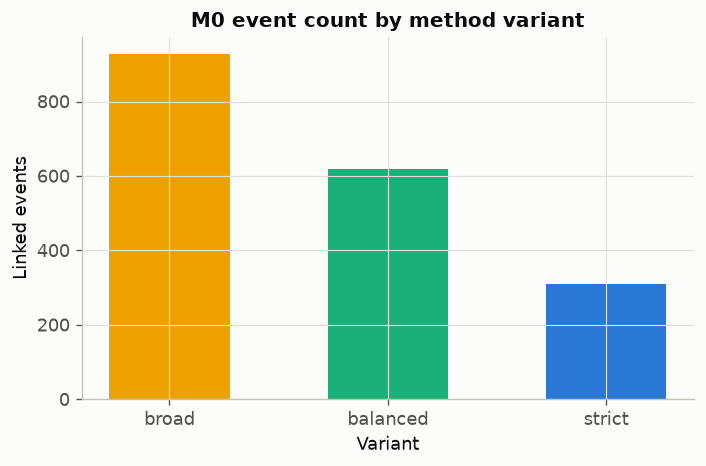

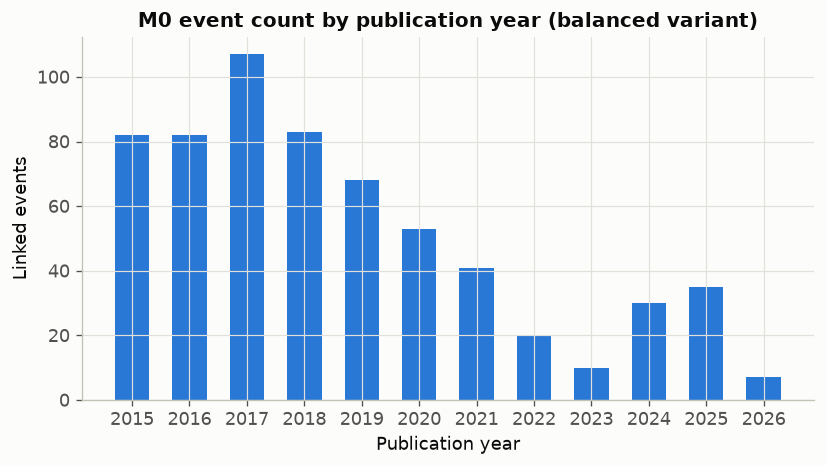

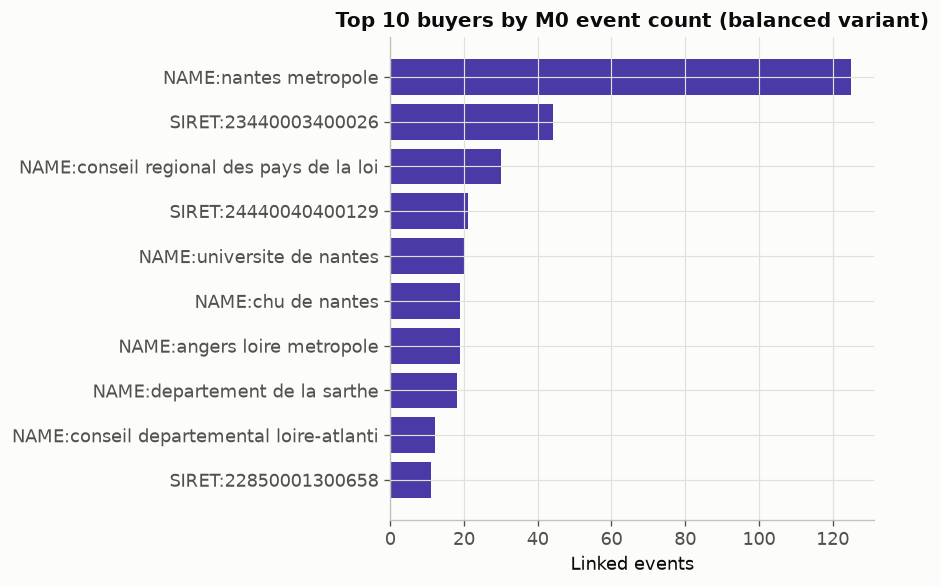

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(method_summary["variant"], method_summary["n_linked_events"],
       color=[CAT["yellow"], CAT["aqua"], CAT["blue"]], width=0.55)
ax.set_title("M0 event count by method variant")
ax.set_ylabel("Linked events")
ax.set_xlabel("Variant")
save_and_show(fig, "08_event_count_by_variant")

ev_balanced = event_counts[event_counts["variant"] == "balanced"]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ev_balanced["publication_year"].astype(str), ev_balanced["n_events"],
       color=CAT["blue"], width=0.6)
ax.set_title("M0 event count by publication year (balanced variant)")
ax.set_xlabel("Publication year")
ax.set_ylabel("Linked events")
save_and_show(fig, "09_event_count_by_year_balanced")

if len(variants["balanced"]):
    top_buyers = variants["balanced"]["buyer_key"].value_counts().head(10)[::-1]
    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.barh([str(b)[:40] for b in top_buyers.index], top_buyers.values, color=CAT["violet"])
    ax.set_title("Top 10 buyers by M0 event count (balanced variant)")
    ax.set_xlabel("Linked events")
    save_and_show(fig, "10_top_buyer_event_counts")